# Marine Heatwaves Comparison: Reproducing Hobday detection method

This notebook assess the capability of `EFESTOMHW` to reproduce the `marineHeatWaves` module for python implementing the Marine Heatwave (MHW) definition of Hobday et al. (2016). This software is demonstrated by applying the MHW definition to a synthetic SST timeseries made by mixing a seasonal oscillation with noise. This was developed as an interactive ipython notebook which the user can run themselves provided they have the required python modules (`numpy`, `scipy`, `datetime`, and `matplotlib`).

In [1]:
# Load required modules
import numpy as np
from datetime import date
from matplotlib import pyplot as plt
%pylab inline
# Load marineHeatWaves definition module
import marineHeatWaves as mhw
#Load my marine heat wave detection code
import sys
sys.path.append('./../')
import detection, utils
from dask.diagnostics import ProgressBar
ProgressBar().register()
from importlib import reload
reload(detection)
reload(utils)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


<module 'utils' from '/mnt/hgfs/stuffbash/Rocky/mhw_stuff/gruber_metrics/EFESTOMHW/notebooks/./../utils.py'>

## Generate synthetic temperature time series

The following code will generate a synthetic daily temperature time series, over the time span 1 Jan 1982 to 31 Dec 2014, using an order-1 autoregressive process. Then it converts data on a 365 day calendar to get rid of leap year problem in the building of the climatology.

In [2]:
# Generate time vector using datetime format (January 1 of year 1 is day 1)
np.random.seed(98274)
t = np.arange(date(1982,1,1).toordinal(),date(2023,12,31).toordinal()+1)
#print(len(t))
dates = [date.fromordinal(tt.astype(int)) for tt in t]
print('Fake MHW dates:', dates[4200], dates[4260])
# Generate synthetic temperature time series
sst = np.zeros(len(t), dtype=np.float64)
sst[0] = 0 # Initial condition
a = 0.85 # autoregressive parameter
known_event = np.zeros(len(t))
known_event[4200:4260] = 1.
for i in range(1,len(t)):
    sst[i] = a*sst[i-1] + 0.75*np.random.randn() + 0.5*np.cos(t[i]*2*np.pi/365.25) + .75*known_event[i]
sst = sst - sst.min() + 5.
import pandas as pd
import xarray as xr
time_pd = pd.date_range(dates[0], dates[-1], freq='1D')
#print(time_pd)
new_sst = sst.reshape((len(sst), 1, 1)).astype(np.float16)
#print(new_sst.shape)
xr_sst = xr.DataArray(new_sst, dims=['time', 'lat', 'lon']).assign_coords({'time':time_pd, 'lat':[0.0], 'lon':[0.0]})
xr_sst = xr_sst.convert_calendar('365_day')
sst = xr_sst.isel(lat=0, lon=0).values
notfeb29s = np.array([d.month==2 and d.day==29 for d in dates])
idx_365 = np.argwhere(notfeb29s==False)
#print(idx_365)
dates = np.array(dates)
dates = dates[idx_365].reshape(-1)
#print(dates, len(sst))
t = np.array([d.toordinal() for d in dates])
#print(t)

Fake MHW dates: 1993-07-02 1993-08-31


## Marine Heatwave Detection

The marineHeatWaves (`mhw`) module consists of a number of functions for the detection and characterization of MHWs. The main function is the detection function (`detect`) which takes as input a time series of temperature (and a corresponding time vector) and outputs a set of detected MHWs. We first run the MHW detection algorithm which returns the variable `mhws`, consisting of the detected MHWs, and `clim`, consisting of the climatological (varying by day-of-year) seasonal cycle and extremes threshold:


In [3]:
mhws, clim = mhw.detect(t, sst, smoothPercentile=True) #climatologyPeriod=[1990,2020],

Then we carry out also our detection within `EFESTOMHW`

In [4]:
from importlib import reload
reload(detection)
DetPeriod = [xr_sst.time.values[0], xr_sst.time.values[-1]]
ClimPeriod = [xr_sst.time.values[0], xr_sst.time.values[-1]]#["1990-01-01", "2020-12-31"]#
PcTile, Win, Smooth, SmoothWin, MinDur, Gap = 0.9, 5, True, 15, 5, 2
myclim, mythresh, mymhw_intensity = detection.detection_complete(var=xr_sst,
                                                                 period_clim=ClimPeriod,
                                                                 period_detect=DetPeriod,
                                                                 pctile=PcTile,
                                                                 window=Win,
                                                                 smoothing=Smooth,
                                                                 smooth_window=SmoothWin,
                                                                 minduration=MinDur,
                                                                 gap=Gap)

selecting period for the climatology...
building climatology rolling window...
calculating percentile...
smoothing with 31 days...
Selecting detection time...
Calculating anomalies...
getting MHW locations in time and space...
Building the mhw_intensity field...


In [5]:
InterestTime = mymhw_intensity.time
selector = xr.DataArray(InterestTime.dt.dayofyear, dims=["time"], coords=[InterestTime])
myclim_r = myclim.sel(dayofyear=selector).isel(lat=0, lon=0).compute()
mythresh_r = mythresh.sel(dayofyear=selector).isel(lat=0, lon=0).compute()
mymhw_intensity_r = mymhw_intensity.compute()
print("Checking Hobday and our climatology values", "%.22f" % clim['seas'][1], "%.22f" % clim['seas'][-3], "%.22f" % myclim_r[1].values, "%.22f" % myclim_r[-3].values)

Checking Hobday and our climatology values 15.8762600806451601442859 15.7804939516129056897853 15.8828125000000000000000 15.7812500000000000000000


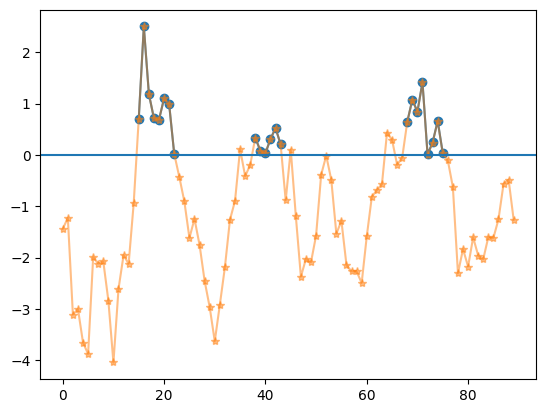

In [6]:
st, ed = 12020, 12110 # checking agreement on one event
myts = mymhw_intensity_r.isel(lat=0, lon=0)[:]
myts = xr.where(myts==-999, np.nan, myts)[st:ed]
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(myts.values, marker='o')
#print(clim)
Hobts = np.where(clim['missing']==False, sst - clim['thresh'], np.nan)[st:ed]
ax.plot(Hobts, alpha=0.5, marker='*')
ax.axhline(0.)
m=0.2
#ax.set_ylim(-m, m)
#print(mymhw_intensity_r.isel(lat=0, lon=0)[st:ed])

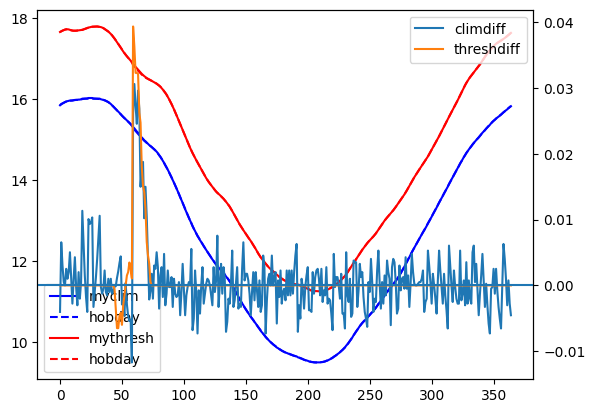

In [7]:
Ly_noLy = 365
diffclim = myclim.isel(lat=0, lon=0) - clim['seas'][0:Ly_noLy]
diffthresh = mythresh.isel(lat=0, lon=0) - clim['thresh'][0:Ly_noLy]
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(myclim.isel(lat=0, lon=0), label='myclim', color='blue')
ax.plot(clim['seas'][0:Ly_noLy], label='hobday', color='blue', ls='dashed')
ax.plot(mythresh.isel(lat=0, lon=0), label='mythresh', color='red')
ax.plot(clim['thresh'][0:Ly_noLy], label='hobday', color='red', ls='dashed')
ax.legend()
Ax = ax.twinx()
Ax.plot(diffclim, label='climdiff')
Ax.plot(diffthresh, label='threshdiff')
Ax.axhline(0.)
#Ax.set_ylim(-1.e-50, 1.e-50)
#ax.set_xlim(55, 60)
Ax.legend(loc='upper right')

There are some discrepancies after the smoothing due to difference between my method and the method of Hobday of doing a running mean...

In [8]:
#print(mymhw_intensity_r.isel(lat=0, lon=0).values)
def label_events(x):
    # x is a numpy array containing the timeseries for all the times of the detection
    #print(x[1338:1351])
    mhw_bool = np.where(x>-999., 1, 0)
    #print(mhw_bool[688:699])
    mhw_diff = np.diff(mhw_bool)
    #print(mhw_diff[0:695])
    start_indices, end_indices = np.argwhere(mhw_diff==1).reshape(-1)+1, np.argwhere(mhw_diff==-1).reshape(-1)+1
    #print(start_indices, end_indices)
    #is_mhw, no_mhw = np.argwhere(x!=-999.).reshape(-1), np.argwhere(x==-999.).reshape(-1)
    #print(is_mhw, no_mhw)
    #is_diff = np.insert(np.diff(is_mhw), 0, 0)
    #print(is_diff)
    #is_start = np.argwhere(is_diff!=1).reshape(-1)
    #is_end = np.delete((is_start - 1), 0)
    #print(is_start, is_end)
    #start_indices = is_mhw[is_start]
    #end_indices = np.insert(is_mhw[is_end], len(is_mhw[is_end]), is_mhw[-1])+1
    nn_events = len(start_indices)
    return start_indices, end_indices, nn_events

st_idx, end_idx, nn_events = label_events(mymhw_intensity_r.isel(lat=0, lon=0).values)
#print("bla", st_idx, len(st_idx))
#print(mymhw_intensity_r.isel(lat=0, lon=0).values.shape)
print("Number of event detected by me:", len(st_idx))
#mymhw_intensity_max = [mymhw_intensity_r.isel(time=slice(st_idx[evnum]-1, end_idx[evnum]+1)).max().values for evnum in range(nn_events)]
#print(mymhw_intensity_max[st_idx].time.values)

Number of event detected by me: 86


Hobday algorithm has detected the following number of MHW events:

In [9]:
mhws['n_events']

86

My Event vs Hobday one:

################################ Mine ############################################
Maximum intensity: 5.1935735887096754 deg. C
Average intensity: 3.337628660865873 deg. C
Duration: 57 days
Cumulative intensity: 190.24483366935476 deg. C-days
Start date: 1993-07-08 00:00:00
End date: 1993-09-02 00:00:00
################################ Hobday ############################################
Maximum intensity: 5.1935735887096754 deg. C
Average intensity: 3.3376286608658745 deg. C
Cumulative intensity: 190.24483366935485 deg. C-days
Duration: 57 days
Start date: 08 July 1993
End date: 02 September 1993


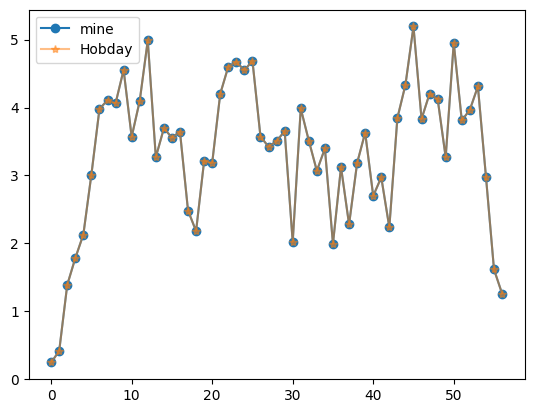

In [10]:
myev = 16#np.argmax(mymhw_intensity_max) # Find largest event
#print(st_idx[myev], end_idx[myev])
mysel_mhw_event = mymhw_intensity_r.isel(time=slice(st_idx[myev], end_idx[myev])).compute()
print("################################ Mine ############################################")
print('Maximum intensity:', mysel_mhw_event.max().values, 'deg. C')
print('Average intensity:', mysel_mhw_event.mean().values, 'deg. C')
print('Duration:', mysel_mhw_event.count().values, 'days')
print('Cumulative intensity:', mysel_mhw_event.mean().values*mysel_mhw_event.count().values, 'deg. C-days')
print('Start date:', mysel_mhw_event.isel(time=0).time.values)
print('End date:', mysel_mhw_event.isel(time=-1).time.values)
ev = 16#np.argmax(mhws['intensity_max']) # Find largest event
print("################################ Hobday ############################################")
print('Maximum intensity:', mhws['intensity_max_relThresh'][ev], 'deg. C')
print('Average intensity:', mhws['intensity_mean_relThresh'][ev], 'deg. C')
print('Cumulative intensity:', mhws['intensity_cumulative_relThresh'][ev], 'deg. C-days')
print('Duration:', mhws['duration'][ev], 'days')
print('Start date:', mhws['date_start'][ev].strftime("%d %B %Y"))
print('End date:', mhws['date_end'][ev].strftime("%d %B %Y"))
plt.plot(mysel_mhw_event.values.squeeze(), label='mine', marker='o')
plt.plot(sst[mhws['index_start'][ev]:mhws['index_end'][ev]+1]-
         clim['thresh'][mhws['index_start'][ev]:mhws['index_end'][ev]+1], alpha=0.5, label='Hobday', marker='*')
plt.legend()

and a closer look at the identified MHW event:

/tmp/ipykernel_5863/1816448034.py:27: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "g-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(dates, mythresh_r, 'g-', linewidth=2, linestyle='dashed')
/tmp/ipykernel_5863/1816448034.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(dates, myclim_r, 'b-', linewidth=2, linestyle='dashed')


Text(0, 0.5, 'SST [$^\\circ$C]')

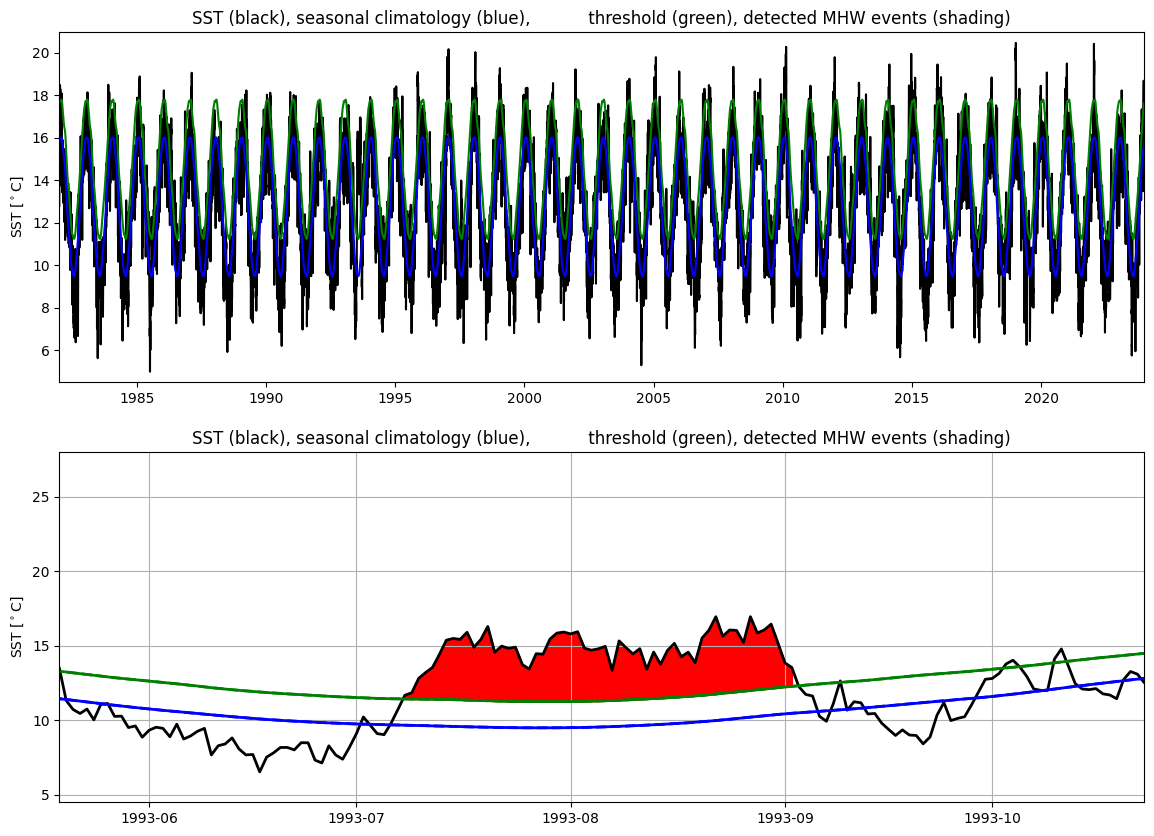

In [11]:
plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
plt.plot(dates, sst, 'k-')
plt.plot(dates, clim['thresh'], 'g-')
plt.plot(dates, clim['seas'], 'b-')
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(dates[0], dates[-1])
plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')
plt.subplot(2,1,2)
# Find indices for all ten MHWs before and after event of interest and shade accordingly
for ev0 in np.arange(ev-10, ev+11, 1):
    t1 = np.where(t==mhws['time_start'][ev0])[0][0]
    t2 = np.where(t==mhws['time_end'][ev0])[0][0]
    plt.fill_between(dates[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                     color=(1,0.6,0.5))
# Find indices for MHW of interest and shade accordingly
t1 = np.where(t==mhws['time_start'][ev])[0][0]
t2 = np.where(t==mhws['time_end'][ev])[0][0]
plt.fill_between(dates[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                 color='r')
# Plot SST, seasonal cycle, threshold, shade MHWs with main event in red
plt.plot(dates, sst, 'k-', linewidth=2)
plt.plot(dates, clim['thresh'], 'g-', linewidth=2)
plt.plot(dates, mythresh_r, 'g-', linewidth=2, linestyle='dashed')
plt.plot(dates, clim['seas'], 'b-', linewidth=2)
plt.plot(dates, myclim_r, 'b-', linewidth=2, linestyle='dashed')
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(dates[t1-50], dates[t2+1+50])
plt.grid()
plt.ylim(clim['seas'].min() - 5, clim['seas'].max() + mhws['intensity_max'][ev] + 5)
plt.ylabel(r'SST [$^\circ$C]')

In [12]:
mysst = (mymhw_intensity.groupby('time.dayofyear') + mythresh).isel(lat=0, lon=0).compute()

Text(0, 0.5, 'SST [$^\\circ$C]')

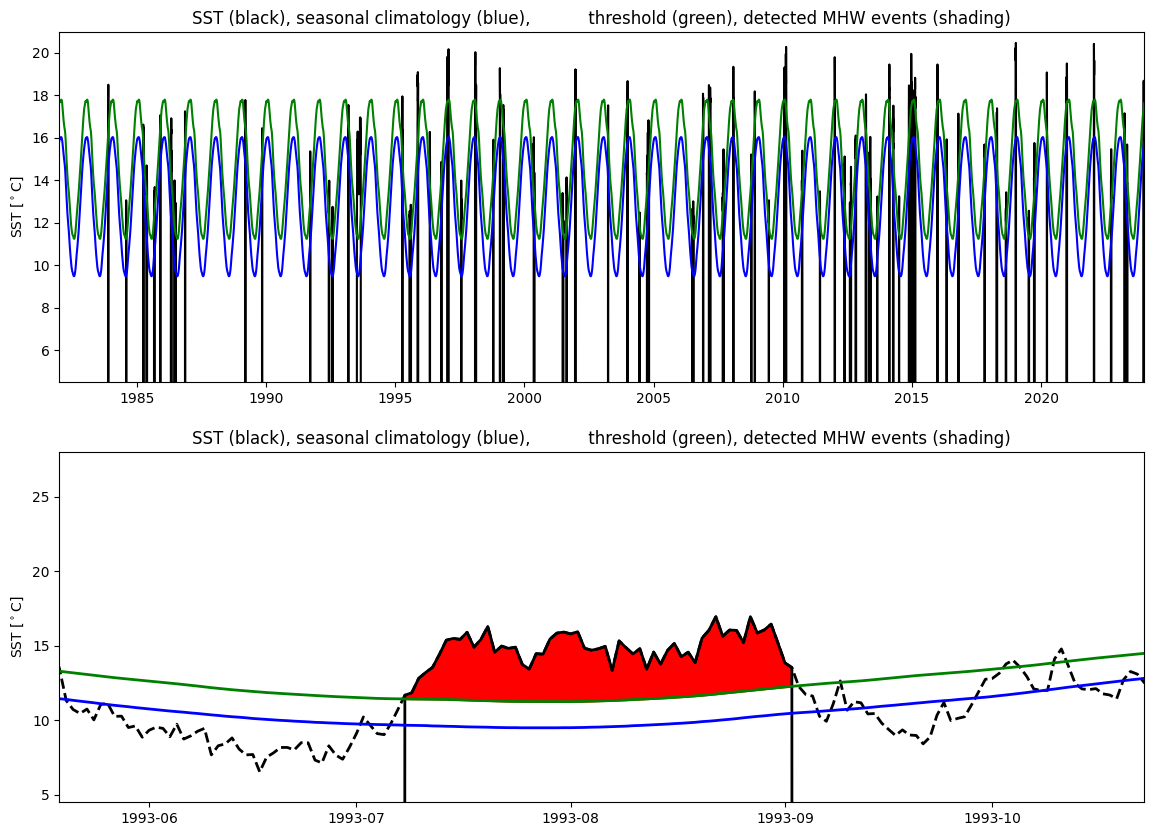

In [13]:
plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
plt.plot(dates, mysst, 'k-')
plt.plot(dates, mythresh_r, 'g-')
plt.plot(dates, myclim_r, 'b-')
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(dates[0], dates[-1])
plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')
plt.subplot(2,1,2)
# Find indices for all ten MHWs before and after event of interest and shade accordingly
for ev0 in np.arange(ev-10, ev+11, 1):
    t1 = np.where(t==mhws['time_start'][ev0])[0][0]
    t2 = np.where(t==mhws['time_end'][ev0])[0][0]
    plt.fill_between(dates[t1:t2+1], mysst[t1:t2+1], mythresh_r[t1:t2+1], \
                     color=(1,0.6,0.5))
# Find indices for MHW of interest and shade accordingly
t1 = np.where(t==mhws['time_start'][ev])[0][0]
t2 = np.where(t==mhws['time_end'][ev])[0][0]
plt.fill_between(dates[t1:t2+1], mysst[t1:t2+1], mythresh_r[t1:t2+1], \
                 color='r')
# Plot SST, seasonal cycle, threshold, shade MHWs with main event in red
plt.plot(dates, sst, color='k', linestyle='dashed', linewidth=2)
plt.plot(dates, mysst, 'k-', linewidth=2)
plt.plot(dates, mythresh_r, 'g-', linewidth=2)
plt.plot(dates, myclim_r, 'b-', linewidth=2)
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(dates[t1-50], dates[t2+1+50])
plt.ylim(clim['seas'].min() - 5, clim['seas'].max() + mhws['intensity_max'][ev] + 5)
plt.ylabel(r'SST [$^\circ$C]')

### Metrics implementation for this event
- Number of days, i.e. the number of days during which this threshold was exceeded;
- Duration, that is, the time period during which this threshold was exceeded;
- Intensity, i.e. how much the climate variable has remained, on average, above the threshold during the event.
- Magnitude, as it reflects the mean value of the climate variable during the event relative to its climatological mean. 
- Abruptness, which describes the speed of the onset to reach the maximum during the event;
- Heterogeneity, or the variance of the intensity during an event.
- Recurrence, that is, the average time between events at a particular location. 
- cumulative intensity, degree heating weeks or severity (defined as the product of mean intensity and duration).

In [14]:
T1, T2, TPeak = mhws['index_start'][ev]-1, mhws['index_end'][ev], mhws['index_peak'][ev]
#print(T1, T2, TPeak)
sst_anom = sst[T1:T2] - clim['seas'][T1:T2]
rate_onset = (sst_anom[TPeak - T1] - (sst_anom[1] + sst_anom[0]) * 0.5 )/ (TPeak - T1 - 0.5)
mean_rate = np.diff(sst_anom)
mean_growth_rate = (mean_rate[mean_rate>0]).mean() / (len(mean_rate[mean_rate>0]))
sst_anom_relthresh = sst[T1:T2] - clim['thresh'][T1:T2]
print('Number of days:', T2-T1)
print('Duration:', dates[T1+1], dates[T2])
print('Intensity:', sst_anom_relthresh.mean())
print('Magnitude:', sst_anom.mean())
print('Abruptness:', rate_onset)
print('Heterogeneity:', sst_anom.std())
print('Recurrence:', ((np.array(mhws['index_start'][1:]) - np.array(mhws['index_end'][:-1])).mean()))
#print(mhws['n_events'] - np.array(mhws['intensity_max']).argsort().argsort())

Number of days: 57
Duration: 1993-07-08 1993-09-02
Intensity: 3.302998549801924
Magnitude: 5.075454513299379
Abruptness: 0.11961073200992564
Heterogeneity: 1.1805761874780754
Recurrence: 164.76470588235293


We got all Marine Heatwaves detected by Hobday method, with the same duration!

[7, 5, 5, 13, 13, 5, 15, 6, 7, 6, 5, 5, 7, 9, 6, 5, 57, 9, 5, 5, 12, 6, 5, 23, 7, 8, 5, 9, 8, 7, 14, 14, 5, 13, 5, 5, 5, 15, 12, 5, 6, 6, 5, 10, 6, 5, 6, 7, 6, 5, 5, 12, 8, 6, 7, 7, 7, 6, 11, 8, 5, 11, 7, 6, 9, 5, 9, 8, 6, 8, 5, 9, 5, 6, 12, 9, 8, 9, 12, 5, 11, 7, 9, 5, 5, 6] [array(7), array(5), array(5), array(13), array(13), array(5), array(15), array(6), array(7), array(6), array(5), array(5), array(7), array(9), array(6), array(5), array(57), array(9), array(5), array(5), array(12), array(6), array(5), array(23), array(7), array(8), array(5), array(9), array(8), array(7), array(14), array(14), array(5), array(13), array(5), array(5), array(5), array(15), array(12), array(5), array(6), array(6), array(5), array(10), array(6), array(5), array(6), array(7), array(6), array(5), array(5), array(12), array(8), array(6), array(7), array(7), array(7), array(6), array(11), array(8), array(5), array(11), array(7), array(6), array(9), array(5), array(9), array(8), array(6), array(8), array(5

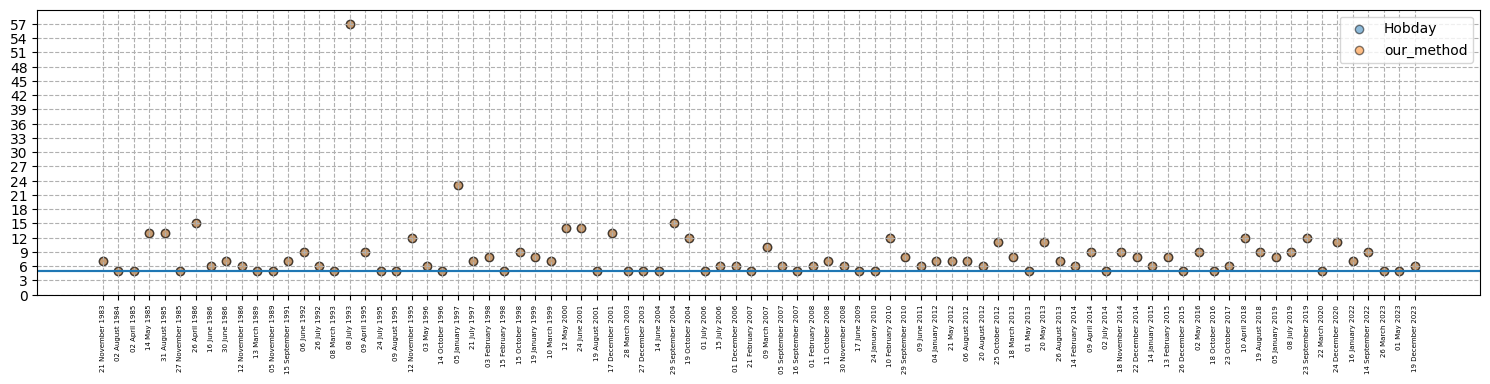

In [15]:
mymhw_intensity_nm = mymhw_intensity_r
mymhw_intensity_r = xr.where(mymhw_intensity_nm!=-999, mymhw_intensity_nm, np.nan)
myvar = [mymhw_intensity_r[:,:,st_idx[i]:end_idx[i]+1].count().values.astype(int) for i in range(len(st_idx)) ]
mydates = [pd.to_datetime(str(mymhw_intensity_r[:,:,st_idx[i]].time.values)).strftime("%d %B %Y") for i in range(len(st_idx)) ]
Hobdayvar = mhws['duration'][:]
print(Hobdayvar, myvar)
print(mydates)
fig = plt.figure(1, figsize=(15,7))
ax = fig.add_subplot(211)
#Ax = fig.add_subplot(212)
Ax=ax
ax.scatter([mhws['date_start'][ev].strftime("%d %B %Y") for ev in range(mhws['n_events'])], Hobdayvar, label='Hobday', edgecolor='k', alpha=0.5)
Ax.scatter(mydates, myvar, label='our_method', edgecolor='k', alpha=0.5)
for tick in ax.get_xticklabels():
    tick.set_rotation(90)
    tick.set_fontsize(5)
for tick in Ax.get_xticklabels():
    tick.set_rotation(90)
    tick.set_fontsize(5)
Ax.set_ylim([0,60])
ax.set_ylim([0,60])
Ax.grid()
ax.grid(ls='dashed')
ax.axhline(5)
Ax.axhline(5)
fig.tight_layout()
ax.legend(loc='best')
Ax.legend(loc='best')
Ax.set_yticks(np.arange(0, 60, 3))